In [1]:
import pandas as pd
import sqlite3


In [2]:
orders = pd.read_csv("/content/orders.csv")
orders.head()


,order_id,user_id,restaurant_id,order_date,total_amount,restaurant_name
0,1,2508,450,18-02-2023,842.97,New Foods Chinese
1,2,2693,309,18-01-2023,546.68,Ruchi Curry House Multicuisine
2,3,2084,107,15-07-2023,163.93,Spice Kitchen Punjabi
3,4,319,224,04-10-2023,1155.97,Darbar Kitchen Non-Veg
4,5,1064,293,25-12-2023,1321.91,Royal Eatery South Indian


In [3]:
users = pd.read_json("/content/users.json")
users.head()


,user_id,name,city,membership
0,1,User_1,Chennai,Regular
1,2,User_2,Pune,Gold
2,3,User_3,Bangalore,Gold
3,4,User_4,Bangalore,Regular
4,5,User_5,Pune,Gold


In [5]:
conn = sqlite3.connect("restaurants.db")


In [6]:
with open("/content/restaurants.sql", "r") as file:
    sql_script = file.read()

conn.executescript(sql_script)


In [7]:
restaurants = pd.read_sql("SELECT * FROM restaurants", conn)
restaurants.head()


,restaurant_id,restaurant_name,cuisine,rating
0,1,Restaurant_1,Chinese,4.8
1,2,Restaurant_2,Indian,4.1
2,3,Restaurant_3,Mexican,4.3
3,4,Restaurant_4,Chinese,4.1
4,5,Restaurant_5,Chinese,4.8


In [8]:
orders_users = pd.merge(
    orders,
    users,
    on="user_id",
    how="left"
)


In [9]:
final_df = pd.merge(
    orders_users,
    restaurants,
    on="restaurant_id",
    how="left"
)


In [10]:
final_df.to_csv("final_food_delivery_dataset.csv", index=False)


In [11]:
from google.colab import files
files.download("final_food_delivery_dataset.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
final_df.info()
final_df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   restaurant_id      10000 non-null  int64  
 3   order_date         10000 non-null  object 
 4   total_amount       10000 non-null  float64
 5   restaurant_name_x  10000 non-null  object 
 6   name               10000 non-null  object 
 7   city               10000 non-null  object 
 8   membership         10000 non-null  object 
 9   restaurant_name_y  10000 non-null  object 
 10  cuisine            10000 non-null  object 
 11  rating             10000 non-null  float64
dtypes: float64(2), int64(3), object(7)
memory usage: 937.6+ KB


,0
order_id,0
user_id,0
restaurant_id,0
order_date,0
total_amount,0
restaurant_name_x,0
name,0
city,0
membership,0
restaurant_name_y,0


In [14]:
final_df.shape
final_df.info()
final_df.head()
final_df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   restaurant_id      10000 non-null  int64  
 3   order_date         10000 non-null  object 
 4   total_amount       10000 non-null  float64
 5   restaurant_name_x  10000 non-null  object 
 6   name               10000 non-null  object 
 7   city               10000 non-null  object 
 8   membership         10000 non-null  object 
 9   restaurant_name_y  10000 non-null  object 
 10  cuisine            10000 non-null  object 
 11  rating             10000 non-null  float64
dtypes: float64(2), int64(3), object(7)
memory usage: 937.6+ KB


,0
order_id,0
user_id,0
restaurant_id,0
order_date,0
total_amount,0
restaurant_name_x,0
name,0
city,0
membership,0
restaurant_name_y,0


<Axes: xlabel='order_date'>

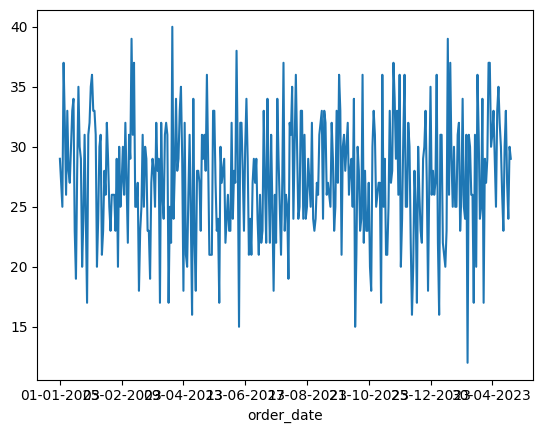

In [15]:
daily_orders = final_df.groupby("order_date").size()
daily_orders.plot()


In [17]:
list(final_df.columns)



['order_id',
 'user_id',
 'restaurant_id',
 'order_date',
 'total_amount',
 'restaurant_name_x',
 'name',
 'city',
 'membership',
 'restaurant_name_y',
 'cuisine',
 'rating']

In [19]:
final_df.columns = final_df.columns.str.strip()


In [21]:
print(list(final_df.columns))



['order_id', 'user_id', 'restaurant_id', 'order_date', 'total_amount', 'restaurant_name_x', 'name', 'city', 'membership', 'restaurant_name_y', 'cuisine', 'rating']


In [22]:
final_df.head()


,order_id,user_id,restaurant_id,order_date,total_amount,restaurant_name_x,name,city,membership,restaurant_name_y,cuisine,rating
0,1,2508,450,18-02-2023,842.97,New Foods Chinese,User_2508,Hyderabad,Regular,Restaurant_450,Mexican,3.2
1,2,2693,309,18-01-2023,546.68,Ruchi Curry House Multicuisine,User_2693,Pune,Regular,Restaurant_309,Indian,4.5
2,3,2084,107,15-07-2023,163.93,Spice Kitchen Punjabi,User_2084,Chennai,Gold,Restaurant_107,Mexican,4.0
3,4,319,224,04-10-2023,1155.97,Darbar Kitchen Non-Veg,User_319,Bangalore,Gold,Restaurant_224,Chinese,4.8
4,5,1064,293,25-12-2023,1321.91,Royal Eatery South Indian,User_1064,Pune,Regular,Restaurant_293,Italian,3.0


In [23]:
for col in final_df.columns:
    print(col)


order_id
user_id
restaurant_id
order_date
total_amount
restaurant_name_x
name
city
membership
restaurant_name_y
cuisine
rating


<Axes: xlabel='order_date'>

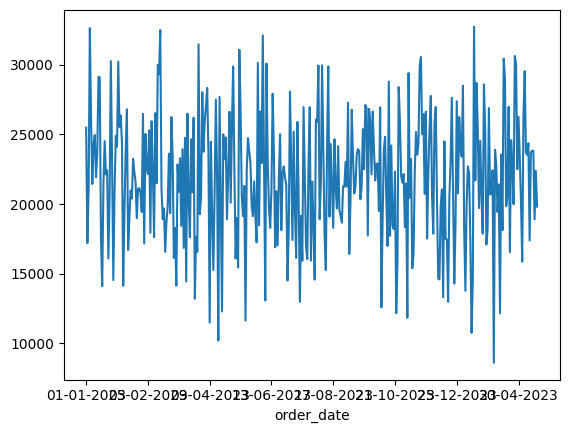

In [24]:
daily_revenue = final_df.groupby("order_date")["total_amount"].sum()
daily_revenue.plot()


In [25]:
final_df.groupby("membership")["total_amount"].sum()


,total_amount
membership,
Gold,3975364.89
Regular,4036259.23


In [27]:
final_df.rename(columns={
    "total_amount": "order_amount",
    "membership": "membership_type",
    "cuisine": "cuisine_type"
}, inplace=True)


In [28]:
daily_revenue = final_df.groupby("order_date")["order_amount"].sum()
final_df.groupby("membership_type")["order_amount"].sum()
final_df.groupby("cuisine_type")["order_amount"].sum()


,order_amount
cuisine_type,
Chinese,1930504.65
Indian,1971412.58
Italian,2024203.80
Mexican,2085503.09


<Axes: xlabel='order_date'>

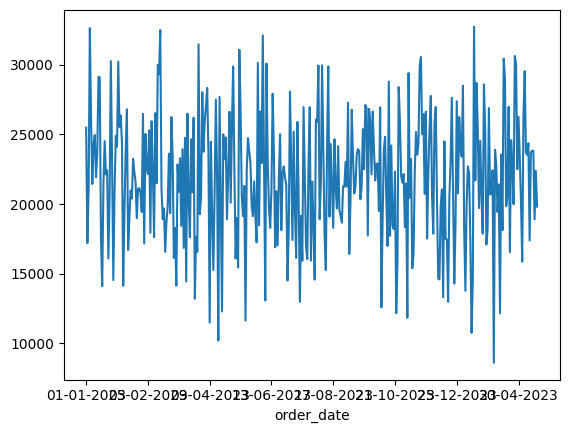

In [29]:
daily_revenue.plot()


In [30]:
final_df.groupby("membership_type")["order_amount"].sum()


,order_amount
membership_type,
Gold,3975364.89
Regular,4036259.23


In [31]:
final_df.groupby("cuisine_type")["order_amount"].sum()


,order_amount
cuisine_type,
Chinese,1930504.65
Indian,1971412.58
Italian,2024203.80
Mexican,2085503.09


In [32]:
final_df.groupby("city")["order_amount"].sum()


,order_amount
city,
Bangalore,2206946.58
Chennai,1990513.03
Hyderabad,1889366.58
Pune,1924797.93


In [33]:
print(final_df.columns)


Index(['order_id', 'user_id', 'restaurant_id', 'order_date', 'order_amount',
       'restaurant_name_x', 'name', 'city', 'membership_type',
       'restaurant_name_y', 'cuisine_type', 'rating'],
      dtype='object')


In [37]:
final_df.rename(columns={
    "total_amount": "order_amount",
    "membership": "membership_type",
    "cuisine": "cuisine_type",
    "restaurant_name_y": "restaurant_name"
}, inplace=True)



In [38]:
final_df.groupby("membership_type")["order_amount"].sum()


,order_amount
membership_type,
Gold,3975364.89
Regular,4036259.23


<Axes: xlabel='order_date'>

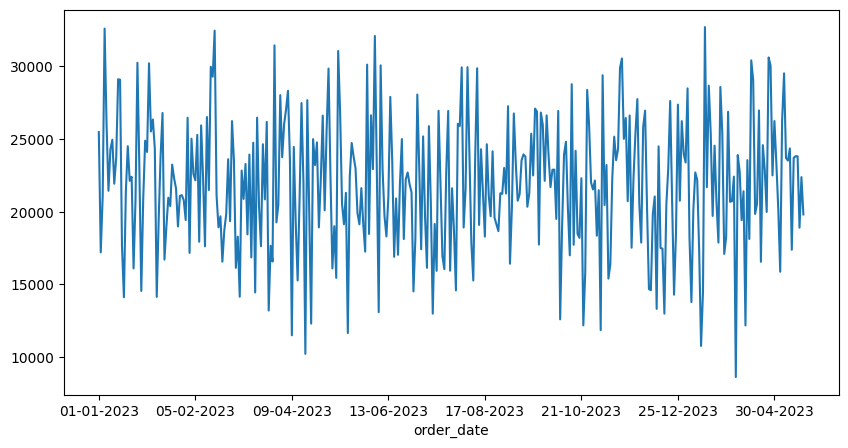

In [39]:
final_df.groupby("order_date")["order_amount"].sum().plot(figsize=(10,5))


In [40]:
final_df.groupby("user_id").size().describe()


,0
count,2883.000000
mean,3.468609
std,1.792682
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,13.000000


<Axes: xlabel='city'>

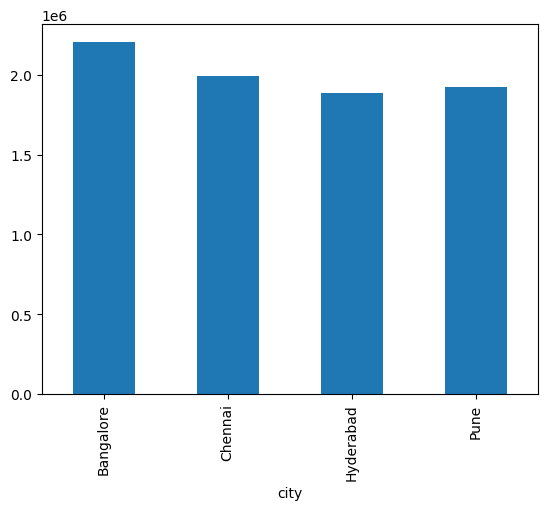

In [41]:
final_df.groupby("city")["order_amount"].sum().plot(kind="bar")


<Axes: xlabel='cuisine_type'>

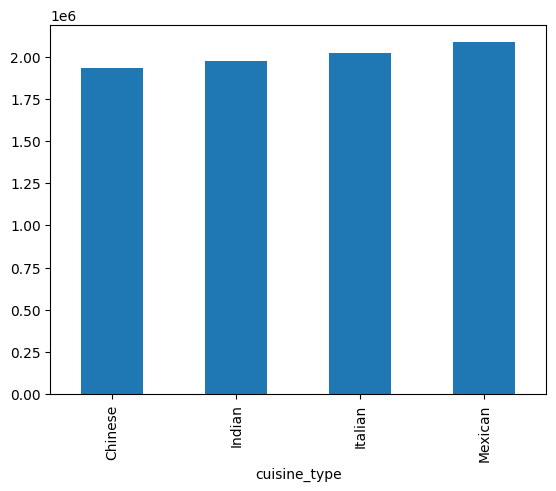

In [42]:
final_df.groupby("cuisine_type")["order_amount"].sum().plot(kind="bar")


<Axes: xlabel='membership_type'>

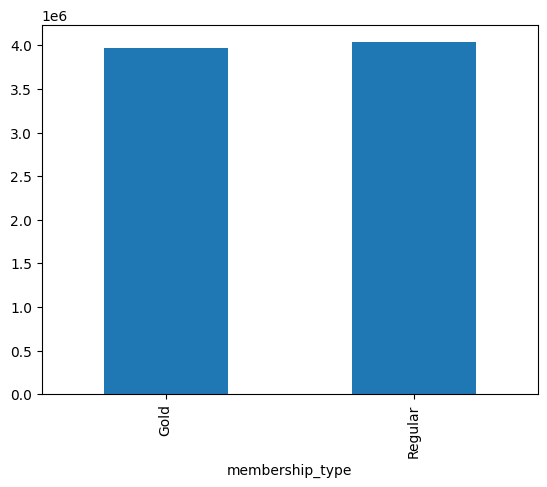

In [43]:
final_df.groupby("membership_type")["order_amount"].sum().plot(kind="bar")


In [45]:
final_df[final_df["city"] == "Hyderabad"]["order_amount"].sum()



np.float64(1889366.58)

In [46]:
final_df.groupby("city")["order_amount"].sum()


,order_amount
city,
Bangalore,2206946.58
Chennai,1990513.03
Hyderabad,1889366.58
Pune,1924797.93


In [47]:
len(final_df[final_df["rating"] >= 4.5])


3374

In [48]:
len(final_df[
    (final_df["membership_type"] == "Gold") &
    (final_df["city"] == "Chennai")
])


1337

In [49]:
final_df[final_df["membership_type"]=="Gold"] \
    .groupby("city")["order_amount"].sum()


,order_amount
city,
Bangalore,994702.59
Chennai,1080909.79
Hyderabad,896740.19
Pune,1003012.32


In [50]:
len(final_df[
    (final_df["membership_type"] == "Gold") &
    (final_df["city"] == "Chennai")
])


1337

In [51]:
len(final_df)


10000